# Figures  
- Contains figures according to manuscripts

In [1]:
# %matplotlib widget
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap
from sklearn.linear_model import LinearRegression

%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import scipy.stats
from scipy.stats import spearmanr, linregress
import matplotlib.gridspec as gridspec

In [2]:
analyse = AnalysisFunc()
reader = DataRead()
utils = DataUtils()
algo = UmapAlgo()
algo_pf = AlgoParFull()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


## Figure 2

In [3]:
# load data
df = reader.data_read_bz2("raw/FN/itr_200.bz2")

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

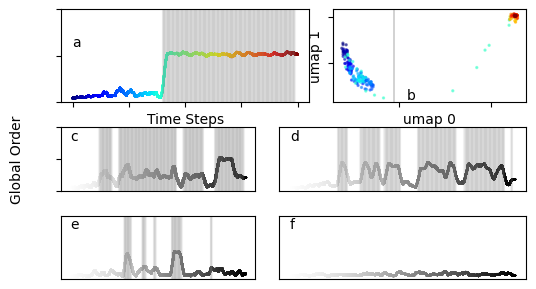

In [14]:
fig = plt.figure(figsize=([6,3.5]))

gs = gridspec.GridSpec(10, 9)
# gs.update(wspace = 1.5, hspace = 0.3)
ax1 = plt.subplot(gs[0:4, 0:5])
# itr 136 of FN
_data = df[39].rolling(800, center=True).mean().ffill().bfill()

cmap = "jet"
with open("../../data/umap_model.pkl", "rb") as f:
    _s, _u = pickle.load(f)
chunk_size = 400
# When you increase or decrease your chunk size, you alter the persistence i.e for how long it stays in sync state
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
# create overlapping chunks with 75% overlap

# _s = StandardScaler().fit(chunks)
scaled_data = _s.transform(chunks)
# Train StandardScaler, Z score normalising values

# _u = u.fit(scaled_data)
embedding = _u.transform(scaled_data)
# Fit Umap i.e it converts 400 dimension data to 2 dimensions and we can create boundary

sep = -0.6
plt.subplots_adjust(hspace=6, wspace=0.8)
ax1.scatter(_data.index, _data, c=_data.index, s=0.5, cmap=cmap)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax1.axvline(l, c="gray", alpha=0.1)
# ax1.set_ylabel("Global Order")
ax1.set_xlabel("Time Steps")
# ax1.set_xlabel('Time Steps')
# ax1.xaxis.set_visible(False)
# ax1.yaxis.set_visible(False)
ax1.set_ylim([0, 1])
ax1.text(0, 0.6, "a")

ax2 = plt.subplot(gs[0:4, 5:9])
# umap
ax2.scatter(
    embedding[:, 0], embedding[:, 1], s=2, c=range(len(chunks)), alpha=0.5, cmap=cmap
)
ax2.set_xlabel("umap 0")
ax2.set_ylabel("umap 1")
ax2.text(0.8, 1, "b")
ax2.axvline(sep, c="k", lw=0.25)
# ax2.xaxis.set_visible(False)
# ax2.yaxis.set_visible(False)
# ax1.set_ylabel('ylabel', labelpad = 0, fontsize = 12)


ax3 = plt.subplot(gs[4:7, 0:4])
# ax2.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax3.xaxis.set_visible(False)
# ax3.yaxis.set_visible(False)
_data = df[136].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax3.scatter(_data.index, _data, c=_data.index, s=1, cmap='Greys')
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax3.axvline(l, c="gray", alpha=0.1)
ax3.set_ylabel('Global Order')
ax3.set_ylim([0, 1])
ax3.text(0, 0.8, "c")

ax4 = plt.subplot(gs[4:7, 4:9], sharex=ax3, sharey=ax3)
# ax3.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax4.xaxis.set_visible(False)
ax4.yaxis.set_visible(False)
_data = df[193].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax4.scatter(_data.index, _data, c=_data.index, s=0.5, cmap='Greys')
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax4.axvline(l, c="gray", alpha=0.1)
ax4.set_ylim([0, 1])
ax4.text(0, 0.8, "d")

ax5 = plt.subplot(gs[7:10, 0:4], sharex=ax3, sharey=ax3)
# ax4.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax5.xaxis.set_visible(False)
ax5.yaxis.set_visible(False)
_data = df[145].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax5.scatter(_data.index, _data, c=_data.index, s=0.5, cmap='Greys')
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax5.axvline(l, c="gray", alpha=0.1)
ax5.set_ylim([0, 1])
ax5.text(0, 0.8, "e")

ax6 = plt.subplot(gs[7:10, 4:9], sharex=ax3, sharey=ax3)
ax6.xaxis.set_visible(False)
ax6.yaxis.set_visible(False)
_data = df[1].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax6.scatter(_data.index, _data, c=_data.index, s=0.5, cmap='Greys')
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax6.axvline(l, c="gray", alpha=0.1)
ax6.set_ylim([0, 1])
# ax6.set_xlabel("time steps")
ax6.text(0, 0.8, "f")

plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax1.get_xticklabels(), visible=False)


plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)

plt.setp(ax3.get_yticklabels(),visible=False)

fig.align_labels()

fig.set_layout_engine(layout="tight")
# plt.savefig('fig2_final.pdf',format='pdf')
# plt.savefig('../../data/results/figures/fig2_final.svg')
# plt.savefig('../../data/results/figures/fig2_final.pdf',format='pdf')